# BLOCK 1

<>:67: SyntaxWarning: invalid escape sequence '\i'
<>:67: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_158418/2622729822.py:67: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel("Order Parameter $r_{\infty}$")


Generating Phase Transition Curve...
Generating Time Series...


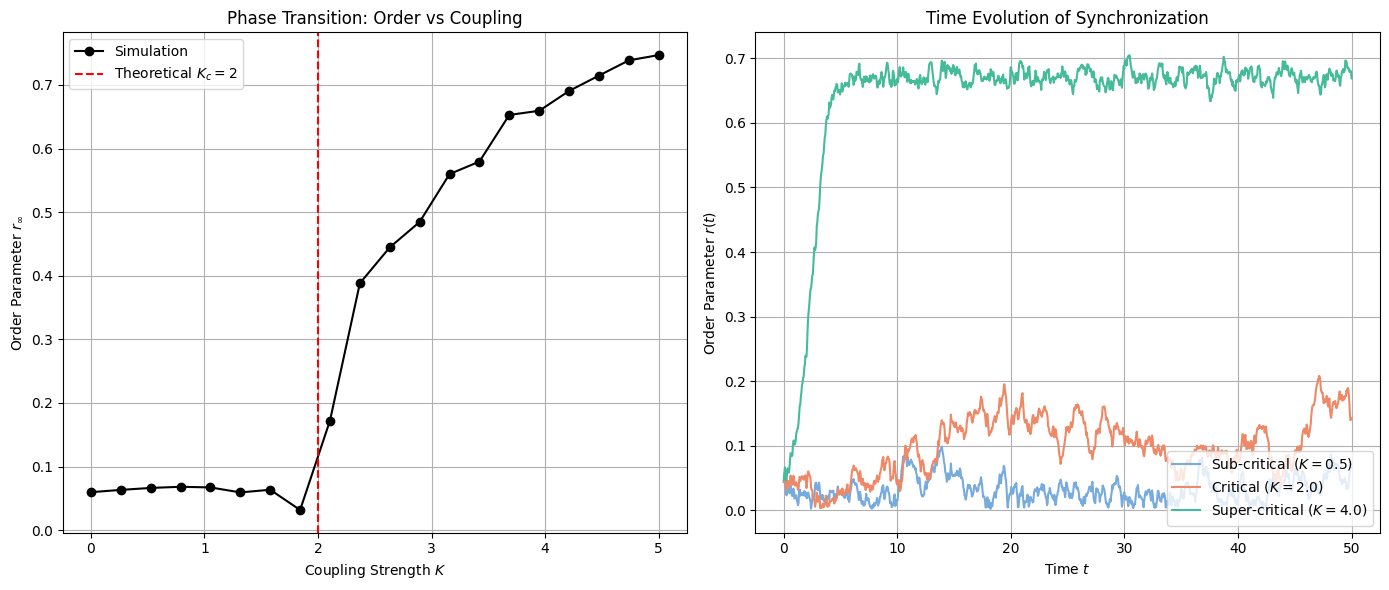

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# CONFIGURATION
N = 1000
dt = 0.05
T = 50
steps = int(T / dt)

# 1. Sweep for Phase Transition (Left Panel)
K_values = np.linspace(0, 5, 20)

# 2. Specific Regimes for Time Evolution (Right Panel)
K_regimes = [0.5, 2.0, 4.0]
labels = ['Sub-critical ($K=0.5$)', 'Critical ($K=2.0$)', 'Super-critical ($K=4.0$)']
colors = ['#77aadd', '#ee8866', '#44bb99'] # Blue, Orange, Green

# --- INITIALIZATION ---
np.random.seed(42) # Fixed seed ensures Kc stays at 2.0
omega = cauchy.rvs(loc=0, scale=1, size=N)
theta_init = np.random.uniform(0, 2*np.pi, N)

def compute_r(theta):
    return np.abs(np.mean(np.exp(1j * theta)))

def kuramoto_step(theta, omega, K, N, dt):
    z = np.mean(np.exp(1j * theta))
    r, psi = np.abs(z), np.angle(z)
    dtheta = omega + K * r * np.sin(psi - theta)
    return theta + dtheta * dt

# EXECUTION
# A. Phase Transition Curve
final_r = []
print("Generating Phase Transition Curve...")
for K in K_values:
    theta = theta_init.copy()
    # Run to steady state
    for _ in range(steps):
        theta = kuramoto_step(theta, omega, K, N, dt)
    final_r.append(compute_r(theta))

# B. Time Evolution Curves
time_series = []
time_axis = np.linspace(0, T, steps)
print("Generating Time Series...")
for K in K_regimes:
    theta = theta_init.copy()
    series = []
    for _ in range(steps):
        theta = kuramoto_step(theta, omega, K, N, dt)
        series.append(compute_r(theta))
    time_series.append(series)

# PLOTTING
plt.figure(figsize=(14, 6))

# Left Panel: The Bifurcation
plt.subplot(1, 2, 1)
plt.plot(K_values, final_r, 'o-', color='black', label='Simulation')
plt.axvline(x=2.0, color='red', linestyle='--', label='Theoretical $K_c=2$')
plt.title("Phase Transition: Order vs Coupling")
plt.xlabel("Coupling Strength $K$")
plt.ylabel("Order Parameter $r_{\infty}$")
plt.legend()
plt.grid(True)

# Right Panel: Time Evolution
plt.subplot(1, 2, 2)
for i, series in enumerate(time_series):
    plt.plot(time_axis, series, label=labels[i], color=colors[i], linewidth=1.5)

plt.title("Time Evolution of Synchronization")
plt.xlabel("Time $t$")
plt.ylabel("Order Parameter $r(t)$")
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.savefig("Figure_1_Corrected.png", dpi=300)
plt.show()

# BLOCK 2

Simulating Safe Regime (K=0.5)...
Simulating Critical Regime (K=1.9)...

--- STOCHASTIC PRECURSOR RESULTS ---
Metric               | Safe (K=0.5)    | Critical (K=1.9)
------------------------------------------------------------
Variance             | 0.000269        | 0.000930
Autocorrelation      | 0.9093         | 0.9656


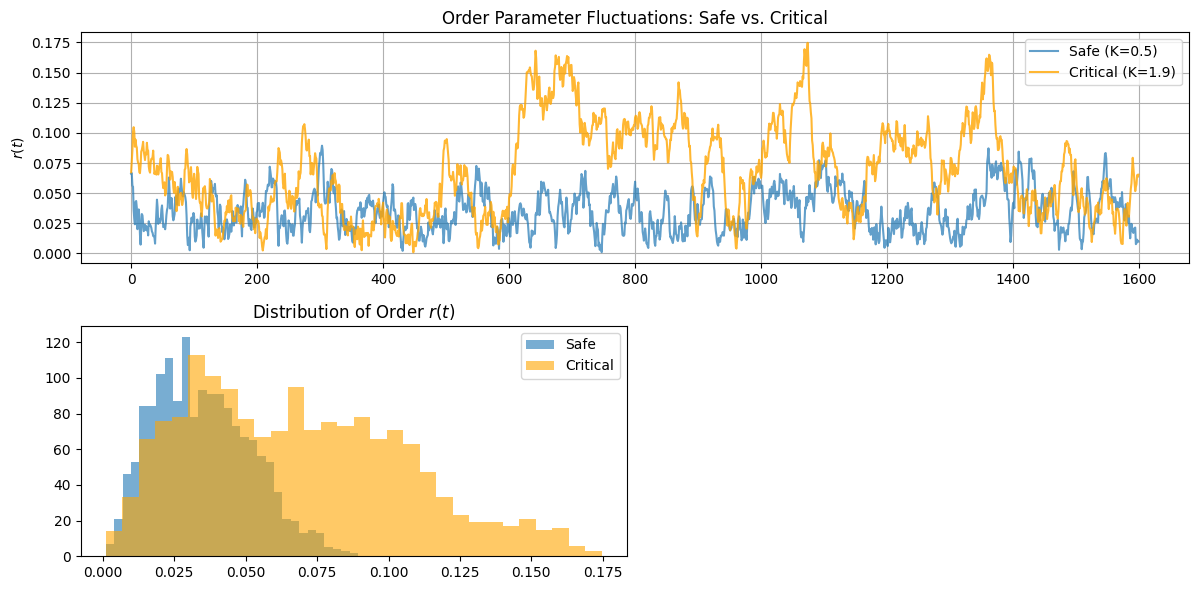

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import cauchy

# CONFIGURATION
N = 1000
T = 100            
dt = 0.05
steps = int(T / dt)
sigma = 0.5        

# Compare two regimes: Safe vs. Critical
scenarios = {
    'Safe': 0.5,     # Far from transition
    'Critical': 1.9  # Just before transition (The "Danger Zone")
}

# INITIALIZATION
np.random.seed(42)
omega = cauchy.rvs(loc=0, scale=1, size=N)
theta_init = np.random.uniform(0, 2*np.pi, N)

def compute_order_parameter(theta):
    z = np.mean(np.exp(1j * theta))
    return np.abs(z), np.angle(z)

def stochastic_kuramoto_step(theta, omega, K, N, dt, sigma):
    """Euler-Maruyama Step"""
    r, psi = compute_order_parameter(theta)

    # Deterministic drift
    drift = omega + K * r * np.sin(psi - theta)

    # Stochastic diffusion (Wiener process)
    diffusion = sigma * np.random.normal(0, np.sqrt(dt), N)

    dtheta = drift * dt + diffusion
    return theta + dtheta, r

# SIMULATION LOOP
results = {}

for name, K in scenarios.items():
    print(f"Simulating {name} Regime (K={K})...")
    theta = theta_init.copy()
    r_series = []

    for _ in range(steps):
        theta, r = stochastic_kuramoto_step(theta, omega, K, N, dt, sigma)
        r_series.append(r)

    results[name] = np.array(r_series)

# DIAGNOSTIC ANALYSIS (The Precursor Check)
window_size = 200  # Size of sliding window

diagnostics = {}
for name, data in results.items():
    steady_data = pd.Series(data[int(steps*0.2):])

    # Rolling metrics
    rolling_var = steady_data.rolling(window=window_size).var()
    rolling_ac = steady_data.rolling(window=window_size).apply(lambda x: x.autocorr(lag=1))

    # Store average diagnostic values for comparison
    diagnostics[name] = {
        'Variance': rolling_var.mean(),
        'Autocorrelation': rolling_ac.mean()
    }

print("\n--- STOCHASTIC PRECURSOR RESULTS ---")
print(f"{'Metric':<20} | {'Safe (K=0.5)':<15} | {'Critical (K=1.9)':<15}")
print("-" * 60)
print(f"{'Variance':<20} | {diagnostics['Safe']['Variance']:.6f}        | {diagnostics['Critical']['Variance']:.6f}")
print(f"{'Autocorrelation':<20} | {diagnostics['Safe']['Autocorrelation']:.4f}         | {diagnostics['Critical']['Autocorrelation']:.4f}")

# VISUALIZATION
plt.figure(figsize=(12, 6))

# Plot R(t) Time Series
plt.subplot(2, 1, 1)
plt.plot(results['Safe'][int(steps*0.2):], label=f'Safe (K={scenarios["Safe"]})', alpha=0.7)
plt.plot(results['Critical'][int(steps*0.2):], label=f'Critical (K={scenarios["Critical"]})', color='orange', alpha=0.8)
plt.title("Order Parameter Fluctuations: Safe vs. Critical")
plt.ylabel("$r(t)$")
plt.legend()
plt.grid(True)

# Plot Histogram of Fluctuations
plt.subplot(2, 2, 3)
plt.hist(results['Safe'][int(steps*0.2):], bins=30, alpha=0.6, label='Safe')
plt.hist(results['Critical'][int(steps*0.2):], bins=30, color='orange', alpha=0.6, label='Critical')
plt.title("Distribution of Order $r(t)$")
plt.legend()

plt.tight_layout()
plt.show()

# BLOCK 3

Simulating Market Projection (Ramp Scenario)...


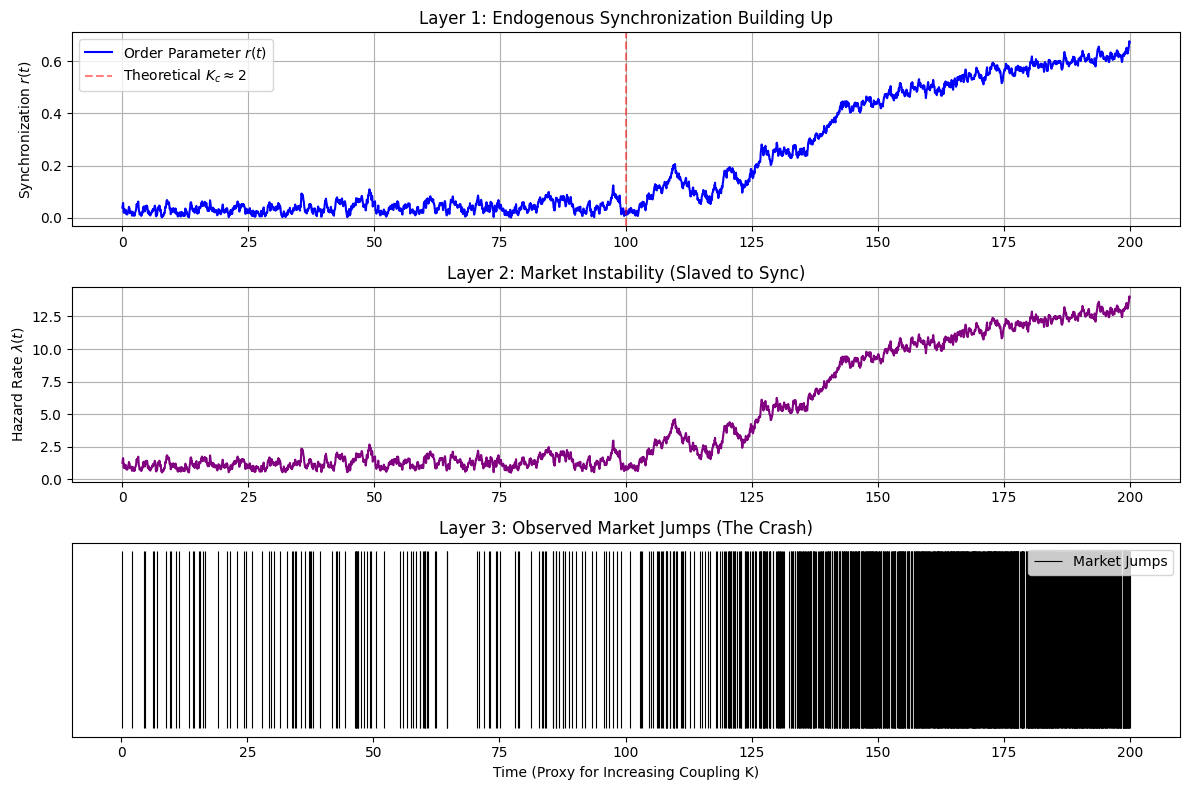

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# CONFIGURATION
N = 1000
T = 200            
dt = 0.05
steps = int(T / dt)
sigma = 0.5       

# Market Coupling Parameters
lambda_base = 0.5  # Background jump 
alpha = 20.0       # Sensitivity

# Dynamic Coupling Ramp (Safe -> Critical -> Super-critical)
K_ramp = np.linspace(0, 4, steps)

# INITIALIZATION
np.random.seed(42) # Fixed seed for reproducibility
omega = cauchy.rvs(loc=0, scale=1, size=N)
theta = np.random.uniform(0, 2*np.pi, N)

# Lists to store history
time_axis = np.linspace(0, T, steps)
r_history = np.zeros(steps)
lambda_history = np.zeros(steps)
jump_events = [] # Store times where a jump occurred

def compute_order(theta):
    z = np.mean(np.exp(1j * theta))
    return np.abs(z), np.angle(z)

# SIMULATION LOOP
print("Simulating Market Projection (Ramp Scenario)...")

for t_idx in range(steps):
    K_current = K_ramp[t_idx]

    # 1. Standard Stochastic Kuramoto Step
    r, psi = compute_order(theta)
    drift = omega + K_current * r * np.sin(psi - theta)
    diffusion = sigma * np.random.normal(0, np.sqrt(dt), N)
    theta += drift * dt + diffusion

    # 2. Market Projection (The New Layer)
    current_lambda = lambda_base + alpha * r

    # 3. Poisson Jump Generation
    p_jump = current_lambda * dt
    if np.random.random() < p_jump:
        jump_events.append(time_axis[t_idx])

    # Store data
    r_history[t_idx] = r
    lambda_history[t_idx] = current_lambda

# VISUALIZATION
plt.figure(figsize=(12, 8))

# Panel 1: The Hidden Mechanism (Synchronization)
plt.subplot(3, 1, 1)
plt.plot(time_axis, r_history, color='blue', label='Order Parameter $r(t)$')
plt.axvline(x=T/2, color='red', linestyle='--', alpha=0.5, label=r'Theoretical $K_c \approx 2$')
plt.ylabel("Synchronization $r(t)$")
plt.title("Layer 1: Endogenous Synchronization Building Up")
plt.legend()
plt.grid(True)

# Panel 2: The Hazard Rate (Intensity)
plt.subplot(3, 1, 2)
plt.plot(time_axis, lambda_history, color='purple', label=r'Jump Intensity $\lambda(t)$')
plt.ylabel(r"Hazard Rate $\lambda(t)$")
plt.title("Layer 2: Market Instability (Slaved to Sync)")
plt.grid(True)

# Panel 3: The Market Observable (Jumps)
plt.subplot(3, 1, 3)
if jump_events:
    plt.vlines(jump_events, 0, 1, color='black', linewidth=0.8, label='Market Jumps')
plt.xlabel("Time (Proxy for Increasing Coupling K)")
plt.yticks([]) # Hide y-axis for barcode
plt.title("Layer 3: Observed Market Jumps (The Crash)")
plt.legend()

plt.tight_layout()
plt.show()

# BLOCK 4

Running Counterfactual Checks...


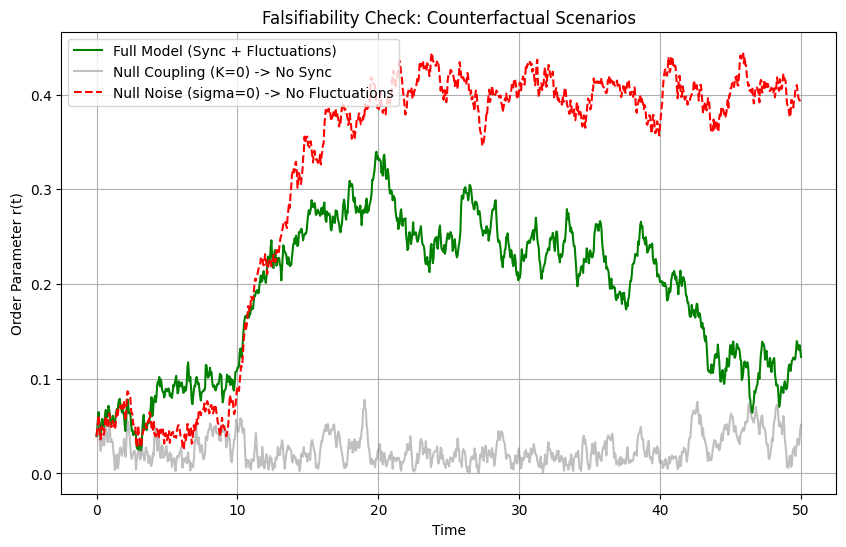

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# CONFIGURATION
N = 1000
T = 50
dt = 0.05
steps = int(T/dt)
time_axis = np.linspace(0, T, steps)

# Shared randomness for fair comparison
np.random.seed(42)
omega_fixed = cauchy.rvs(loc=0, scale=1, size=N)
theta_start = np.random.uniform(0, 2*np.pi, N)

def run_scenario(K_val, sigma_val):
    theta = theta_start.copy()
    r_history = []

    for _ in range(steps):
        # Compute Order
        z = np.mean(np.exp(1j * theta))
        r, psi = np.abs(z), np.angle(z)
        r_history.append(r)

        # Dynamics
        drift = omega_fixed + K_val * r * np.sin(psi - theta)
        diffusion = sigma_val * np.random.normal(0, np.sqrt(dt), N)
        theta += drift * dt + diffusion

    return np.array(r_history)

# EXECUTE COUNTERFACTUALS
print("Running Counterfactual Checks...")
# Scenario 1: The Full Model
r_full = run_scenario(K_val=2.5, sigma_val=0.5)

# Scenario 2: No Coupling
r_null_coupling = run_scenario(K_val=0.0, sigma_val=0.5)

# Scenario 3: No Noise
r_null_noise = run_scenario(K_val=2.5, sigma_val=0.0)

# VISUALIZATION
plt.figure(figsize=(10, 6))
plt.plot(time_axis, r_full, label='Full Model (Sync + Fluctuations)', color='green')
plt.plot(time_axis, r_null_coupling, label='Null Coupling (K=0) -> No Sync', color='gray', alpha=0.5)
plt.plot(time_axis, r_null_noise, label='Null Noise (sigma=0) -> No Fluctuations', color='red', linestyle='--')

plt.title("Falsifiability Check: Counterfactual Scenarios")
plt.xlabel("Time")
plt.ylabel("Order Parameter r(t)")
plt.legend()
plt.grid(True)
plt.show()

# BLOCK 5

<>:81: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:81: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_208258/4153400935.py:81: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Observable Hazard Rate $\lambda(t)$")
/tmp/ipykernel_208258/4153400935.py:83: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Intensity $\lambda(t)$")


Running Test A: Observability Gap...


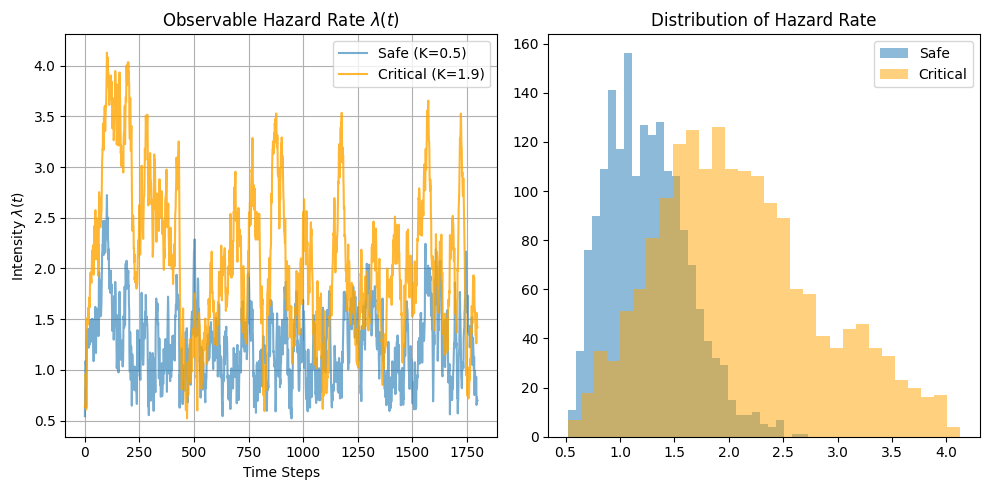


 Running Test B: Parameter Robustness Sweep...
Scenario        | Sigma | N     | Safe AC    | Crit AC    | Signal Increase
---------------------------------------------------------------------------
Low Noise       | 0.2   | 1000  | 0.9033     | 0.9678     | +7.1%
Baseline        | 0.5   | 1000  | 0.9093     | 0.9664     | +6.3%
High Noise      | 0.8   | 1000  | 0.8910     | 0.9379     | +5.3%
Small Pop       | 0.5   | 500   | 0.8849     | 0.9373     | +5.9%
Large Pop       | 0.5   | 2000  | 0.8520     | 0.9411     | +10.5%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# CONFIGURATION 
base_params = {
    'N': 1000,
    'dt': 0.05,
    'T': 100,
    'alpha': 20.0,
    'lambda_0': 0.5
}

# Robustness Sweep Scenarios
robustness_scenarios = [
    {'sigma': 0.2, 'N': 1000, 'label': 'Low Noise'},
    {'sigma': 0.5, 'N': 1000, 'label': 'Baseline'},
    {'sigma': 0.8, 'N': 1000, 'label': 'High Noise'},
    {'sigma': 0.5, 'N': 500,  'label': 'Small Pop'},
    {'sigma': 0.5, 'N': 2000, 'label': 'Large Pop'},
]

def run_simulation(K, sigma, N, dt, T, alpha, lambda_0):
    """Runs a single stochastic realization and returns time series."""
    steps = int(T / dt)
    np.random.seed(42)

    # Init
    omega = cauchy.rvs(loc=0, scale=1, size=N)
    theta = np.random.uniform(0, 2*np.pi, N)

    r_series = []
    lambda_series = []

    for _ in range(steps):
        # Order Parameter
        z = np.mean(np.exp(1j * theta))
        r, psi = np.abs(z), np.angle(z)

        # Hazard Rate Projection (Linear mapping as per Block 3)
        curr_lambda = lambda_0 + alpha * r

        # Update Dynamics
        drift = omega + K * r * np.sin(psi - theta)
        diffusion = sigma * np.random.normal(0, np.sqrt(dt), N)
        theta += drift * dt + diffusion

        r_series.append(r)
        lambda_series.append(curr_lambda)

    return np.array(r_series), np.array(lambda_series)

def calculate_diagnostics(series, window=200):
    """Computes Lag-1 Autocorr on the steady state."""
    cut = int(len(series) * 0.2)
    clean_series = pd.Series(series[cut:])

    # Metric: Mean Lag-1 Autocorrelation
    ac = clean_series.rolling(window=window).apply(lambda x: x.autocorr(lag=1)).mean()
    var = clean_series.var()
    return ac, var

# PART A: OBSERVABILITY CHECK (Visual)
print("Running Test A: Observability Gap...")
K_safe = 0.5
K_crit = 1.9
sigma_base = 0.5
N_base = 1000

# Run Safe
_, lam_safe = run_simulation(K_safe, sigma_base, N_base, 0.05, 100, 20.0, 0.5)
# Run Critical
_, lam_crit = run_simulation(K_crit, sigma_base, N_base, 0.05, 100, 20.0, 0.5)

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(lam_safe[200:], label='Safe (K=0.5)', alpha=0.6)
plt.plot(lam_crit[200:], label='Critical (K=1.9)', color='orange', alpha=0.8)
plt.title("Observable Hazard Rate $\lambda(t)$")
plt.xlabel("Time Steps")
plt.ylabel("Intensity $\lambda(t)$")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(lam_safe[200:], bins=30, alpha=0.5, label='Safe')
plt.hist(lam_crit[200:], bins=30, color='orange', alpha=0.5, label='Critical')
plt.title("Distribution of Hazard Rate")
plt.legend()
plt.tight_layout()
plt.show()

# --- PART B: ROBUSTNESS TABLE ---
print("\n Running Test B: Parameter Robustness Sweep...")
print(f"{'Scenario':<15} | {'Sigma':<5} | {'N':<5} | {'Safe AC':<10} | {'Crit AC':<10} | {'Signal Increase':<15}")
print("-" * 75)

for scen in robustness_scenarios:
    # Run Safe
    _, lam_safe = run_simulation(K_safe, scen['sigma'], scen['N'], 0.05, 100, 20.0, 0.5)
    ac_safe, _ = calculate_diagnostics(lam_safe)

    # Run Critical
    _, lam_crit = run_simulation(K_crit, scen['sigma'], scen['N'], 0.05, 100, 20.0, 0.5)
    ac_crit, _ = calculate_diagnostics(lam_crit)

    # Calculate Signal Strength (How much did AC jump?)
    increase = ((ac_crit - ac_safe) / ac_safe) * 100

    print(f"{scen['label']:<15} | {scen['sigma']:<5} | {scen['N']:<5} | {ac_safe:.4f}     | {ac_crit:.4f}     | +{increase:.1f}%")